Utilize XOpt to perform optimization on scenario A again.

In [2]:
import os, sys
current_dir = os.getcwd()
sys.path.append(os.path.join(current_dir, '..'))
# import importlib
# import experiments_utils
# importlib.reload(experiments_utils)
from experiments_utils import *
from configs import *

Scanario A with conventional optimization methods

In [3]:
# # scenario A setting
# CURRENT_BOUNDS = (0.01, 1.5)
# EPSILON = 1e-3

# # parameter setting
# # N_RUNS_A = 1000
# N_RUNS_A = 1
# A_BEAMLINE_LEN = 10



# METHODS_A = [
#     ("Nelder-Mead", None),
#     ("L-BFGS-B", "2-point"),
#     ("SLSQP", "2-point"),
#     ("COBYLA", None),
#     ("trust-constr", "2-point"),
# ]

# A_VARS = {
#     1: ["I", "current", lambda x: x],
#     3: ["I2", "current", lambda x: x],
# }
# A_OBJ = {
#     8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
#     9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
# }

In [4]:
# # default parameter version
# METHOD_OPTIONS = {
#     "L-BFGS-B": {
#         "maxcor": 10,
#         "ftol": 2.220446049250313e-09,
#         "gtol": 1e-5,
#         "eps": 1e-8,
#         "maxfun": 15000,
#         "maxiter": 15000,
#         "maxls": 20,
#     },
#     "SLSQP": {
#         "maxiter": 100,
#         "ftol": 1e-6,
#         "iprint": 1,
#         "disp": False,
#         "eps": 1.4901161193847656e-08,
#         "finite_diff_rel_step": None,
#         "workers": None,
#     },
#     "trust-constr": {
#         "xtol": 1e-8,
#         "gtol": 1e-8,
#         "barrier_tol": 1e-8,
#         "sparse_jacobian": None,
#         "maxiter": 1000,
#         "verbose": 0,
#         "finite_diff_rel_step": None,
#         "initial_constr_penalty": 1.0,
#         "initial_tr_radius": 1.0,
#         "initial_barrier_parameter": 0.1,
#         "initial_barrier_tolerance": 0.1,
#         "factorization_method": None,
#         "disp": False,
#         "workers": None,
#     },
#     "Nelder-Mead": {
#         "maxiter": None,
#         "maxfev": None,
#         "disp": False,
#         "return_all": False,
#         "initial_simplex": None,
#         "xatol": 1e-4,
#         "fatol": 1e-4,
#         "adaptive": False,
#     },
#     "COBYLA": {
#         "rhobeg": 1.0,
#         "tol": 1e-4,
#         "maxiter": 1000,
#         "disp": 0,
#         "catol": None,
#         "f_target": float("-inf"),
#     },
# }

use_log: False
use noise: False

▶ Scenario A — Nelder-Mead  (1 runs)
  Nelder-Mead             run 1/1  MSE=2.506e-08  nit=34  nfev=65   t=11.00s

▶ Scenario A — L-BFGS-B+jac  (1 runs)
  L-BFGS-B                run 1/1  MSE=9.212e-14  nit=8   nfev=45   t=6.80s

▶ Scenario A — SLSQP+jac  (1 runs)
  SLSQP                   run 1/1  MSE=1.155e-07  nit=9   nfev=29   t=4.93s

▶ Scenario A — COBYLA  (1 runs)
  COBYLA                  run 1/1  MSE=3.170e-05  nit=-1  nfev=69   t=10.64s

▶ Scenario A — trust-constr+jac  (1 runs)
  trust-constr            run 1/1  MSE=5.713e-14  nit=24  nfev=54   t=8.49s

 🎯 SCENARIO A: Robustness (Tol < 1) & Discovered Physics State vs Reference
 method_tag  conv_rate nit_mean nfev_mean wall_time_mean final_mse_mean    I      I_ref      I2     I2_ref  8_alpha_x 9_alpha_y
      COBYLA    100%     69.0      69.0      10.638 s       3.17e-05    0.9461 A 0.8218 A 1.1825 A 1.0430 A  -0.0080   -0.0018 
    L-BFGS-B    100%      8.0      45.0       6.801 s       9.21

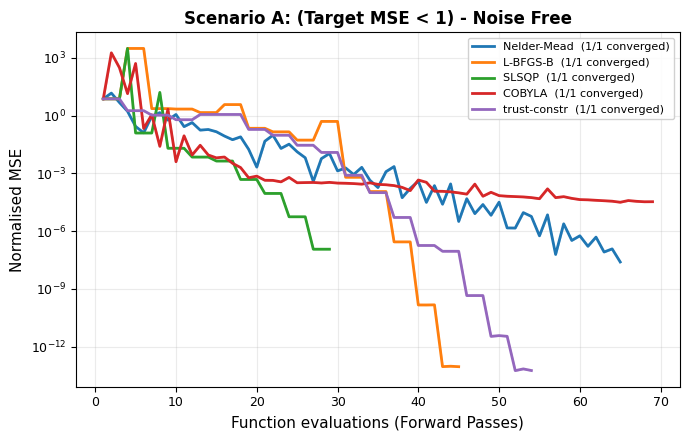

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
─────────────────────────────────────────────────────────
  Nelder-Mead            2.5065e-08     0.8511     1.1297
  L-BFGS-B               9.2122e-14     0.7438     0.5786
  SLSQP                  1.1551e-07     0.8509     1.1296
  COBYLA                 3.1699e-05     0.9461     1.1825
  trust-constr           5.7128e-14     0.7438     0.5786
  Reference FELsim S1 currents: I=0.8218 A, I2=1.0430 A

  Overall best across all methods/runs:
    Method: trust-constr,  MSE=5.7128e-14
    I=0.7438 A	    I2=0.5786 A	

{'I': np.float64(0.7438158854748629), 'I2': np.float64(0.5785975237995599)}

In [5]:
results_A, df_A, final_summary = run_scenario_A(
    CURRENT_BOUNDS,
    EPSILON,
    N_RUNS_A,
    FELSIM_S1_CURRENTS,
    A_OBJ,
    A_VARS,
    A_BEAMLINE_LEN,
    METHODS_A,
    scale="log",
    METHOD_OPTIONS=METHOD_OPTIONS,
)
display_results(results_A, A_VARS, FELSIM_S1_CURRENTS)

In [5]:
# save the results
# experiment_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_results_v4.pkl")
# save_results(results_A, df_A, final_summary, experiment_save_path)

In [6]:
# load the results
# experiment_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_results_v4.pkl")
# results_A, df_A, final_summary = load_results(experiment_save_path)

scenario B with conventional optimization methods

In [ ]:
# # scenario B setting
# # CURRENT_BOUNDS_BC = (0.01, 5.0)
# # EPSILON = 1e-3

# # REF_I_1 = 0.8218
# # REF_I_3 = 1.0430
# # REF_I = [REF_I_1, REF_I_3]

# # parameter setting
# # N_RUNS_B = 1000
# N_RUNS_B = 1
# A_BEAMLINE_LEN = 138

# METHODS_B = [
#     ("Nelder-Mead", None),
#     ("L-BFGS-B", "2-point"),
#     ("SLSQP", "2-point"),
#     ("COBYLA", None),
#     ("trust-constr", "2-point"),
# ]


# # variables and constraints for scenario B
# def _v(name):
#     return [name, "current", lambda x, _n=name: x]

# STAGES_B = [
#     (
#         "Stage 1 Doublet",
#         {1: _v("I"), 3: _v("I2")},
#         {
#             8: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.0},
#             ],
#             9: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         10,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 1},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 1},
#         },
#     ),
#     (
#         "Stage 2 Chrom.1",
#         {10: _v("I")},
#         {15: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         16,
#         {"I": {"bounds": CURRENT_BOUNDS_BC, "start": 1}},
#     ),
#     (
#         "Stage 3 Triplet1",
#         {16: _v("I"), 18: _v("I2"), 20: _v("I3")},
#         {
#             25: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             26: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         27,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 5},
#             "I3": {"bounds": CURRENT_BOUNDS_BC, "start": 3},
#         },
#     ),
#     (
#         "Stage 4 Chrom.2",
#         {27: _v("I")},
#         {32: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         33,
#         {"I": {"bounds": CURRENT_BOUNDS_BC, "start": 1}},
#     ),
#     (
#         "Stage 5 DblTriplet",
#         {37: _v("I"), 35: _v("I2"), 33: _v("I3")},
#         {
#             37: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "envelope"], "goal": 2.0, "weight": 1},
#                 {"measure": ["y", "envelope"], "goal": 2.0, "weight": 1},
#             ]
#         },
#         38,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 0.28},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 2.65},
#             "I3": {"bounds": CURRENT_BOUNDS_BC, "start": 2.69},
#         },
#     ),
#     (
#         "Stage 6 Chrom.3",
#         {50: _v("I")},
#         {55: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         56,
#         {"I": {"bounds": CURRENT_BOUNDS_BC, "start": 1}},
#     ),
#     (
#         "Stage 7 IP",
#         {56: _v("I"), 58: _v("I2")},
#         {
#             59: [
#                 {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1},
#                 {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1},
#             ]
#         },
#         60,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#         },
#     ),
#     (
#         "Stage 8 Doublet2",
#         {61: _v("I"), 63: _v("I2")},
#         {
#             68: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             69: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         70,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#         },
#     ),
#     (
#         "Stage 9 Chrom.4",
#         {70: _v("I")},
#         {75: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         76,
#         {"I": {"bounds": CURRENT_BOUNDS_BC, "start": 1}},
#     ),
#     (
#         "Stage 10 Triplet3",
#         {76: _v("I"), 78: _v("I2"), 80: _v("I3")},
#         {
#             85: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             86: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         87,
#         {
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I3": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#         },
#     ),
#     (
#         "Stage 11 UND Match",
#         {87: _v("Ic"), 93: _v("I"), 95: _v("I2"), 97: _v("I3")},
#         {
#             92: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 0.5}],
#             117: [
#                 {"measure": ["x", "alpha"], "goal": ALPHA_XM, "weight": 1},
#                 {"measure": ["y", "alpha"], "goal": ALPHA_YM, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": BETA_XM, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": BETA_YM, "weight": 1},
#             ],
#         },
#         118,
#         {
#             "Ic": {"bounds": CURRENT_BOUNDS_BC, "start": 4},
#             "I": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#             "I3": {"bounds": CURRENT_BOUNDS_BC, "start": 2},
#         },
#     ),
# ]



In [ ]:
from scenario_B_utils import run_scenario_B 

results_B, df_B, final_beamline_B = run_scenario_B(
    STAGES_B=STAGES_B,
    PARTICLES=PARTICLES,
    EXCEL_PATH=EXCEL_PATH,
    METHODS_B=METHODS_B,
    N_RUNS_B=N_RUNS_B,         
    METHOD_OPTIONS=METHOD_OPTIONS,
    verbose=True
)

display(df_B)


▶ 🚀 Starting Scenario B (11-Stage Sequential) — Method: Nelder-Mead (1 runs total)
    Stage 1 Doublet           MSE=2.045e-04  nfev=62   t=9.83s
    Stage 2 Chrom.1           MSE=3.694e-06  nfev=16   t=5.98s
    Stage 3 Triplet1          MSE=1.204e-03  nfev=116  t=74.36s
    Stage 4 Chrom.2           MSE=6.303e-06  nfev=16   t=13.67s
    Stage 5 DblTriplet        MSE=2.268e-02  nfev=482  t=425.92s
    Stage 6 Chrom.3           MSE=8.237e-07  nfev=16   t=23.43s
    Stage 7 IP                MSE=1.225e-02  nfev=92   t=146.67s
    Stage 8 Doublet2          MSE=6.744e+01  nfev=100  t=158.77s
    Stage 9 Chrom.4           MSE=9.780e-06  nfev=16   t=28.06s
    Stage 10 Triplet3         MSE=8.870e-02  nfev=387  t=773.87s
    Stage 11 UND Match        MSE=1.035e+01  nfev=308  t=993.43s
✓ Nelder-Mead pipeline execution completed, total time: 2654.11s

▶ 🚀 Starting Scenario B (11-Stage Sequential) — Method: L-BFGS-B (1 runs total)
    Stage 1 Doublet           MSE=1.489e-04  nfev=51   t=7.46s


scenario C with conventional optimization methods

Running Scenario C: Combined ~11-parameter (IP+UND)...
use_log: False | use_noise: False

▶ Scenario C — Nelder-Mead  (1 runs)


  Nelder-Mead             run 1/1  MSE=7.222e+13  nit=290 nfev=937  t=2736.83s

▶ Scenario C — L-BFGS-B+jac  (1 runs)
  L-BFGS-B                run 1/1  MSE=3.386e+32  nit=1   nfev=408  t=1157.39s

▶ Scenario C — SLSQP+jac  (1 runs)
  SLSQP                   run 1/1  MSE=3.388e+32  nit=1   nfev=12   t=34.18s

▶ Scenario C — COBYLA  (1 runs)
  COBYLA                  run 1/1  MSE=1.216e+14  nit=-1  nfev=90   t=256.34s

▶ Scenario C — trust-constr+jac  (1 runs)
  trust-constr            run 1/1  MSE=1.033e+15  nit=183 nfev=3768 t=11264.16s

 🎯 SCENARIO C: Robustness (Tol < 0.001) & Discovered Physics State vs Reference
 method_tag  conv_rate nit_mean nfev_mean wall_time_mean final_mse_mean   I_56   I_56_ref   I_58   I_58_ref   I_61   I_61_ref   I_63   I_63_ref   I_76   I_76_ref   I_78   I_78_ref   I_80   I_80_ref   I_87   I_87_ref   I_93   I_93_ref   I_95   I_95_ref   I_97   I_97_ref 59_envelope_x       117_alpha_x      
      COBYLA     0%      90.0       90.0     256.336 s        NaN  

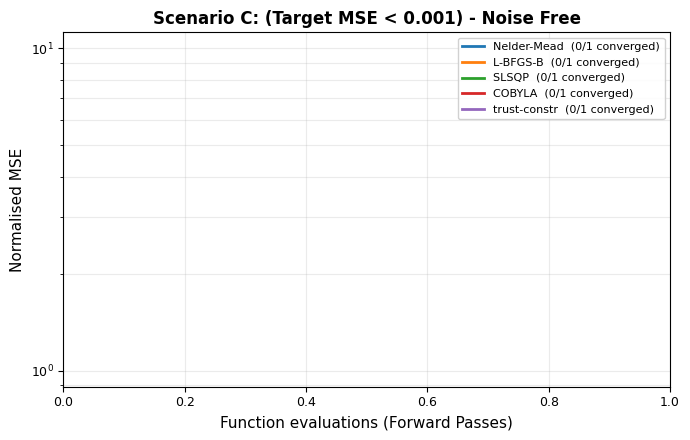

In [ ]:
# # ==========================================
# # 🚀 Scenario C Execution (Combined 11-parameter)
# # ==========================================
# print("Running Scenario C: Combined ~11-parameter (IP+UND)...")

# CURRENT_BOUNDS_BC = (0.01, 5.0) # Expanded bounds since we are dealing with a larger optimization space
# EPSILON = 1e-3
# N_RUNS_C = 1
# C_BEAMLINE_LEN = 118

# METHODS_C = [
#     ("Nelder-Mead", None),
#     ("L-BFGS-B", "2-point"),
#     ("SLSQP", "2-point"),
#     ("COBYLA", None),
#     ("trust-constr", "2-point"),
# ]

# # Ensure variables are uniquely named to prevent DataFrame column collisions
# def _v_C(name): return [name, "current", lambda x, _n=name: x]

# C_VARS = {
#     56: _v_C("I_56"), 58: _v_C("I_58"),
#     61: _v_C("I_61"), 63: _v_C("I_63"),
#     76: _v_C("I_76"), 78: _v_C("I_78"), 80: _v_C("I_80"),
#     87: _v_C("I_87"), 93: _v_C("I_93"), 95: _v_C("I_95"), 97: _v_C("I_97")
# }

# # Objectives: IP spot + UND beta matching
# C_OBJ = {
#     59: [
#         {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1.0},
#         {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1.0},
#     ],
#     117: [
#         {"measure": ["x", "alpha"], "goal": ALPHA_XM, "weight": 1.0},
#         {"measure": ["y", "alpha"], "goal": ALPHA_YM, "weight": 1.0},
#         {"measure": ["x", "beta"], "goal": BETA_XM, "weight": 1.0},
#         {"measure": ["y", "beta"], "goal": BETA_YM, "weight": 1.0},
#     ]
# }


In [ ]:
from scenario_C_utils import run_scenario_C
# Run it through the universal single-stage runner
results_C, df_C, final_summary_C = run_scenario_C(
    scenario_name="C",
    CURRENT_BOUNDS=CURRENT_BOUNDS_BC,
    EPSILON=EPSILON,
    N_RUNS=N_RUNS_C,
    REF_CURRENTS=FELSIM_S1_CURRENTS,
    OBJ=C_OBJ,
    VARS=C_VARS,
    BEAMLINE_LEN=C_BEAMLINE_LEN,
    METHODS=METHODS_C,
    METHOD_OPTIONS=METHOD_OPTIONS,
    verbose=True
)